In [1]:
import os
import matplotlib.pyplot as plt

import numpy as np
import tensorflow as tf

from deepface import DeepFace


KNOWN_DIR = "known_faces"
TEST_DIR = "test_images"

face_db = {}


26-09-21 19:37:32 - ⚠️ 
 ⚠️ DEPRECATION WARNING:
 Running 'pip install deepface' alone will no longer be sufficient and will
 NOT install a default backend in an upcoming major release.

 Currently, TensorFlow is included by default, but this behavior will be deprecated.
 Please explicitly specify your preferred backend engine when installing:

   -> pip install deepface[tensorflow]
   -> pip install deepface[pytorch]

 Otherwise, you will encounter 'module not found' errors.



In [2]:
def cosine_similarity(vector_1, vector_2):
    numerator = np.dot(
        vector_1,
        vector_2,
    )

    denominator = (
        np.linalg.norm(vector_1)
        * np.linalg.norm(vector_2)
    )

    return numerator / denominator

In [3]:
MODEL_NAME = "Dlib"


def get_embedding(image_path):
    try:
        with tf.device("/CPU:0"):
            result = DeepFace.represent(
                img_path=image_path,
                model_name=MODEL_NAME,
                detector_backend="mtcnn",
                enforce_detection=True,
                align=True,
            )

        if not result:
            return None

        return np.asarray(
            result[0]["embedding"],
            dtype=np.float32,
        )

    except Exception as error:
        print(f"Ошибка: {error}")
        return None

In [4]:
def add_person(name, image_path):
    embedding = get_embedding(image_path)

    if embedding is None:
        print(
            f"{name}: лицо не найдено"
        )
        return

    face_db[name] = embedding

    print(
        f"{name} добавлен."
    )

In [5]:
import os


def fill_face_db():
    face_db.clear()

    for file_name in sorted(
        os.listdir(KNOWN_DIR)
    ):
        if not file_name.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):
            continue

        image_path = os.path.join(
            KNOWN_DIR,
            file_name,
        )

        name = os.path.splitext(
            file_name
        )[0]

        name = name.replace(
            "_",
            " ",
        )

        add_person(
            name,
            image_path,
        )

    print(
        f"\nВсего людей в базе: "
        f"{len(face_db)}"
    )

In [6]:
def find_person(
    image_path,
    threshold=0.92,
):
    embedding = get_embedding(
        image_path
    )

    if embedding is None:
        print(
            "Лицо на изображении не найдено."
        )
        return None

    if not face_db:
        print(
            "База лиц пустая."
        )
        return None

    best_name = None
    best_similarity = -1

    for name, saved_embedding in face_db.items():
        similarity = cosine_similarity(
            embedding,
            saved_embedding,
        )

        print(
            f"{name}: "
            f"{similarity:.4f}"
        )

        if similarity > best_similarity:
            best_similarity = similarity
            best_name = name

    if best_similarity >= threshold:
        print(
            f"\nНайден человек: "
            f"{best_name}"
        )
        print(
            f"Сходство: "
            f"{best_similarity:.4f}"
        )

        return best_name

    print(
        "\nТакого человека нет в базе."
    )

    print(
        f"Максимальное сходство: "
        f"{best_similarity:.4f}"
    )

    return None

In [7]:
def test_all_images():
    known_correct = 0
    unknown_correct = 0
    errors = 0
    total = 0
    error_images = []

    for file_name in sorted(os.listdir(TEST_DIR)):
        if not file_name.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):
            continue

        image_path = os.path.join(
            TEST_DIR,
            file_name,
        )

        print("\n" + "=" * 50)
        print(f"Изображение: {file_name}")
        print("=" * 50)

        result = find_person(image_path)

        total += 1

        if file_name.startswith("unknown"):
            if result is None:
                unknown_correct += 1
            else:
                errors += 1

                error_images.append({
                    "path": image_path,
                    "expected": "Unknown",
                    "predicted": result,
                })

        else:
            expected_name = (
                file_name
                .split("_test_")[0]
                .replace("_", " ")
            )

            if result == expected_name:
                known_correct += 1
            else:
                errors += 1

                error_images.append({
                    "path": image_path,
                    "expected": expected_name,
                    "predicted": (
                        result
                        if result is not None
                        else "Unknown"
                    ),
                })

    correct = known_correct + unknown_correct
    accuracy = correct / total * 100

    print("\nИтог:")
    print(f"Известные: {known_correct}/15")
    print(f"Неизвестные: {unknown_correct}/3")
    print(f"Ошибки: {errors}")
    print(f"Accuracy: {accuracy:.2f}%")

    return {
        "known": known_correct,
        "unknown": unknown_correct,
        "errors": errors,
        "accuracy": accuracy,
        "error_images": error_images,
    }

In [8]:
fill_face_db()

W0000 00:00:1790001452.289535  230398 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1790001452.422232  230398 gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was false.
I0000 00:00:1790001452.423488  230398 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6144 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


Abdullah Gul добавлен.
Adrien Brody добавлен.
Alejandro Toledo добавлен.
Alvaro Uribe добавлен.
Amelie Mauresmo добавлен.

Всего людей в базе: 5



Изображение: Abdullah_Gul_test_1.jpg
Abdullah Gul: 0.9509
Adrien Brody: 0.8584
Alejandro Toledo: 0.8569
Alvaro Uribe: 0.8809
Amelie Mauresmo: 0.8754

Найден человек: Abdullah Gul
Сходство: 0.9509

Изображение: Abdullah_Gul_test_2.jpg
Abdullah Gul: 0.8921
Adrien Brody: 0.8441
Alejandro Toledo: 0.8744
Alvaro Uribe: 0.8813
Amelie Mauresmo: 0.8805

Такого человека нет в базе.
Максимальное сходство: 0.8921

Изображение: Abdullah_Gul_test_3.jpg
Abdullah Gul: 0.9614
Adrien Brody: 0.8295
Alejandro Toledo: 0.8276
Alvaro Uribe: 0.8618
Amelie Mauresmo: 0.8382

Найден человек: Abdullah Gul
Сходство: 0.9614

Изображение: Adrien_Brody_test_1.jpg
Abdullah Gul: 0.8131
Adrien Brody: 0.9574
Alejandro Toledo: 0.8615
Alvaro Uribe: 0.9097
Amelie Mauresmo: 0.8630

Найден человек: Adrien Brody
Сходство: 0.9574

Изображение: Adrien_Brody_test_2.jpg
Abdullah Gul: 0.8166
Adrien Brody: 0.9705
Alejandro Toledo: 0.8641
Alvaro Uribe: 0.9055
Amelie Mauresmo: 0.8551

Найден человек: Adrien Brody
Сходство: 0.9705

Из

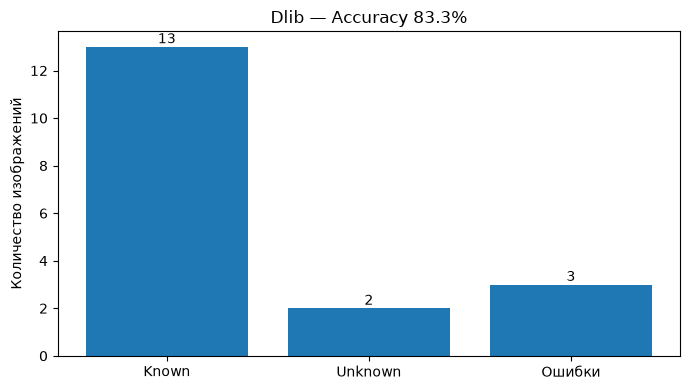

In [9]:
results = test_all_images()


labels = [
    "Known",
    "Unknown",
    "Ошибки",
]

values = [
    results["known"],
    results["unknown"],
    results["errors"],
]


plt.figure(
    figsize=(7, 4)
)

plt.bar(
    labels,
    values,
)

plt.ylabel(
    "Количество изображений"
)

plt.title(
    f"{MODEL_NAME} — Accuracy "
    f"{results['accuracy']:.1f}%"
)

for index, value in enumerate(values):
    plt.text(
        index,
        value + 0.15,
        str(value),
        ha="center",
    )

plt.tight_layout()
plt.show()

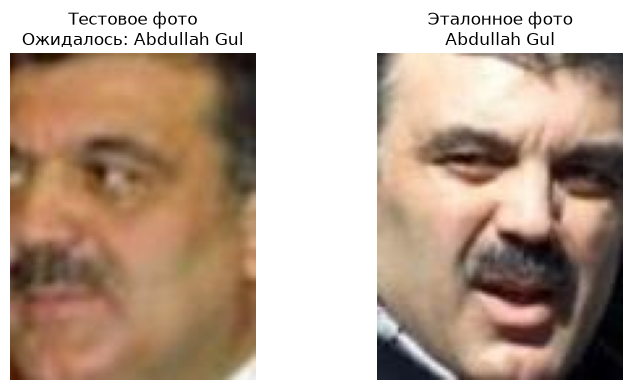

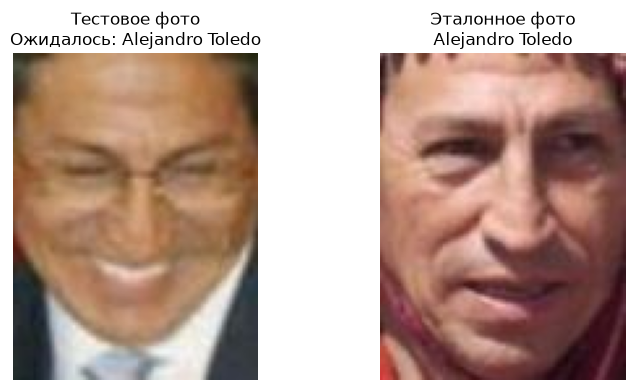

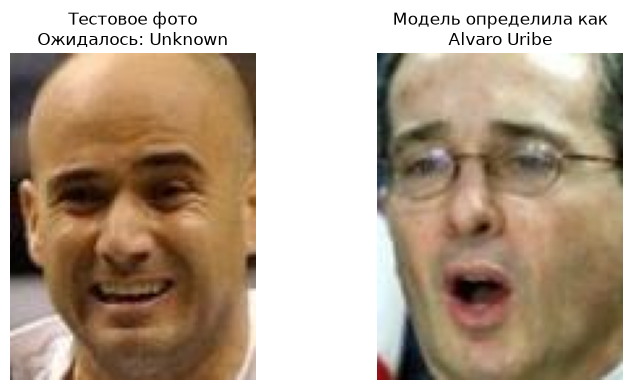

In [10]:
import matplotlib.pyplot as plt
from PIL import Image


for error in results["error_images"]:
    test_image = Image.open(
        error["path"]
    ).convert("RGB")

    predicted_name = error["predicted"]

    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(test_image)
    plt.axis("off")
    plt.title(
        f"Тестовое фото\n"
        f"Ожидалось: {error['expected']}"
    )

    plt.subplot(1, 2, 2)

    if predicted_name != "Unknown":
        reference_file = (
            predicted_name.replace(" ", "_")
            + ".jpg"
        )

        reference_path = os.path.join(
            KNOWN_DIR,
            reference_file,
        )

        reference_image = Image.open(
            reference_path
        ).convert("RGB")

        plt.imshow(reference_image)
        plt.axis("off")
        plt.title(
            f"Модель определила как\n"
            f"{predicted_name}"
        )

    else:
        expected_file = (
            error["expected"].replace(" ", "_")
            + ".jpg"
        )

        expected_path = os.path.join(
            KNOWN_DIR,
            expected_file,
        )

        reference_image = Image.open(
            expected_path
        ).convert("RGB")

        plt.imshow(reference_image)
        plt.axis("off")
        plt.title(
            "Эталонное фото\n"
            f"{error['expected']}"
        )

    plt.tight_layout()
    plt.show()